In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

# ModelCreation & ModelTraining

In [2]:
df = pd.read_csv('Student_Performance_ml.csv')

In [3]:
df.head() 

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [4]:
df.corr(numeric_only=True)

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


<Axes: xlabel='Performance Index', ylabel='Previous Scores'>

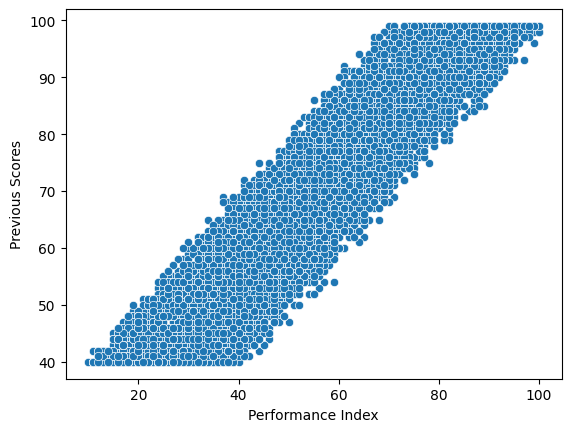

In [5]:
sns.scatterplot(data=df,x='Performance Index',y = 'Previous Scores')

In [6]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({"Yes":1,"No":0})
# Data Cleaning Should be always --> Before Assigning X and Y 

In [7]:
X = df.drop(columns="Performance Index") #It can be multiple columns so it must be 2D(input--> Because it can  have multiple columns)
Y = df['Performance Index'] #This should always be 1D Because output(target) column should be only one 

In [8]:
Xtrain,Xtest,Ytrain,Ytest = train_test_split( X,Y,train_size = 0.8,random_state=42) 
# random_state = 42 --> to fix the values (42)- it is not mandatary to keep the same number 42 we can keep any number
# But 42 is recommended                                      

* Interview Question

What is Random_State ?

In [9]:
# print(Xtrain)

In [10]:
#Model Creation
model = LinearRegression()

In [11]:
# Model Training --> it learns the pattern the straight line(Best fit line) from xtrain(input) and ytrain(output)
model.fit(Xtrain,Ytrain) #now everthing will be stored in the model object

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[2.85,1.02,0.61,0.48,0.19]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Hours Studied','Previous Scores','Extracurricular Activities', 'Sleep Hours','Sample Question Papers Practiced']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-33.92
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [12]:
model.intercept_  #

np.float64(-33.921946215556126)

In [13]:
model.coef_  # Coefficient

array([2.85248393, 1.0169882 , 0.60861668, 0.47694148, 0.19183144])

Intercept Conclusion

Base or initial value of "Performance Index" is -33.921946215556126
when all features qual to zero 


# Model Evaluation

* Train Data

In [14]:
Ytrain #Ytrain(actual)
#ytrain_predicted(predicted_values)

9254    36.0
1561    25.0
1670    59.0
6087    22.0
6669    40.0
        ... 
5734    48.0
5191    51.0
5390    44.0
860     20.0
7270    24.0
Name: Performance Index, Length: 8000, dtype: float64

Syntax :

    * model.predict(X)
    * ytrain_predicted = model.predict(Xtrain)
    * ytest_predicted = model.predict(xtest)

In [15]:
Ytest_predicted = model.predict(Xtest)
Ytrain_predicted = model.predict(Xtrain)

Syntax for metrics

metricname(actual_output,predicted_output)

r2_score?

r2_score(ytrain,ytrain_predicted)

r2_score(ytest,ytest_predicted)


In [16]:
r2_score(Ytrain,Ytrain_predicted)

0.9886898790682355

In [17]:
r2_score(Ytest,Ytest_predicted)

0.9889832909573145

Because 

In [18]:
mean_absolute_error(Ytrain,Ytrain_predicted)

1.619305483033428

In [19]:
mean_squared_error(Ytrain,Ytrain_predicted)

4.169735849525007

In [20]:
root_mean_squared_error(Ytrain,Ytrain_predicted)

2.0419931071198567

The Model Captures the outlier Pattern so the model is good

By Comparing RMSE and MAE

RMSE - 2.0419931071198567 == 1.619305483033428 - MAE

By this we can conlude that the model is Good!
